In [60]:
import numpy as np
from pathlib import Path
import json
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt

from phd_helpers.experiments import get_sensor_loc, parse_tekscan, F2P, build_sensor_mesh, project_sensor, project_sensor_new, project_sensor_complex, force_per_frame
from phd_helpers.AbaqusPostprocessing import inp2pv, get_field_path, get_field_df, add_field_to_mesh, get_history_path

In [2]:
cal_path = Path('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Experimental/LabData/MethodDevelopment/tekscanCalibration/20260601/Movie1.asm')
test_path = Path('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Experimental/LabData/MethodDevelopment/tekscanCalibration/20260601/Movie3.asm')
fps = 64
time_window = 5 # s (window over which to average frames for each force level)
FRAME_WINDOW = fps * time_window

## Get calibration frame ranges
- get 5s frame ranges for each force level

In [3]:
# load calibration frames
cal_imgs = parse_tekscan(cal_path, 2)
cal_Rs = np.sum(cal_imgs, axis=(1, 2))

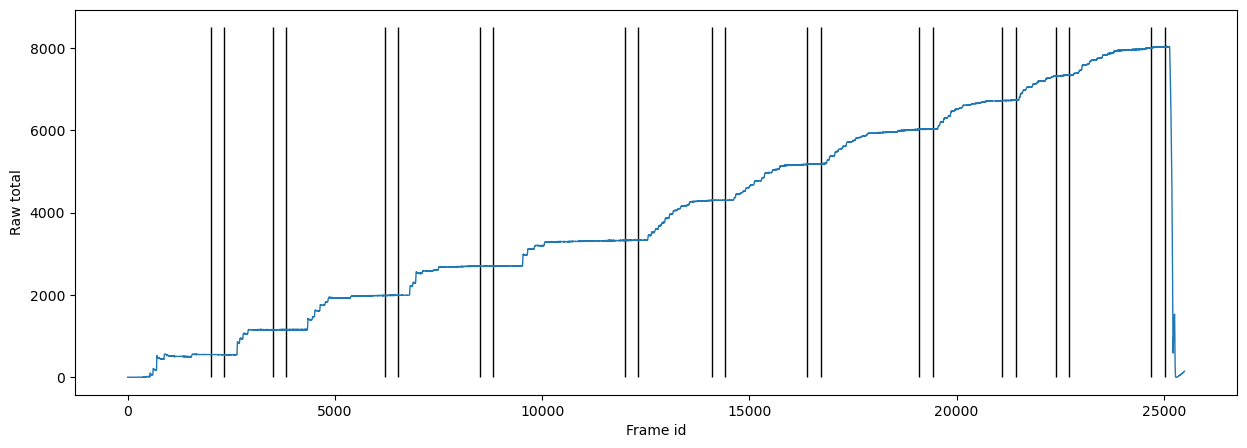

In [4]:
cal_ids = {
    10: 2000,
    25: 3500,
    50: 6200,
    75: 8500,
    100: 12000,
    150: 14100,
    200: 16400,
    250: 19100,
    300: 21100,
    350: 22400,
    400: 24700
}

nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(15*ncols, 5*nrows))

for val in cal_ids.values():
    ax.vlines([val, val+FRAME_WINDOW], ymin=0, ymax=8500, color='black', linewidth=1)

ax.plot(np.arange(len(cal_Rs)), cal_Rs, linewidth=1)
ax.set_xlabel('Frame id')
ax.set_ylabel('Raw total')
plt.show()

## Get test frame ranges
- get 5s frame ranges for each force level

In [5]:
# load calibration frames
test_imgs = parse_tekscan(test_path, 2)
test_Rs = np.sum(test_imgs, axis=(1, 2))

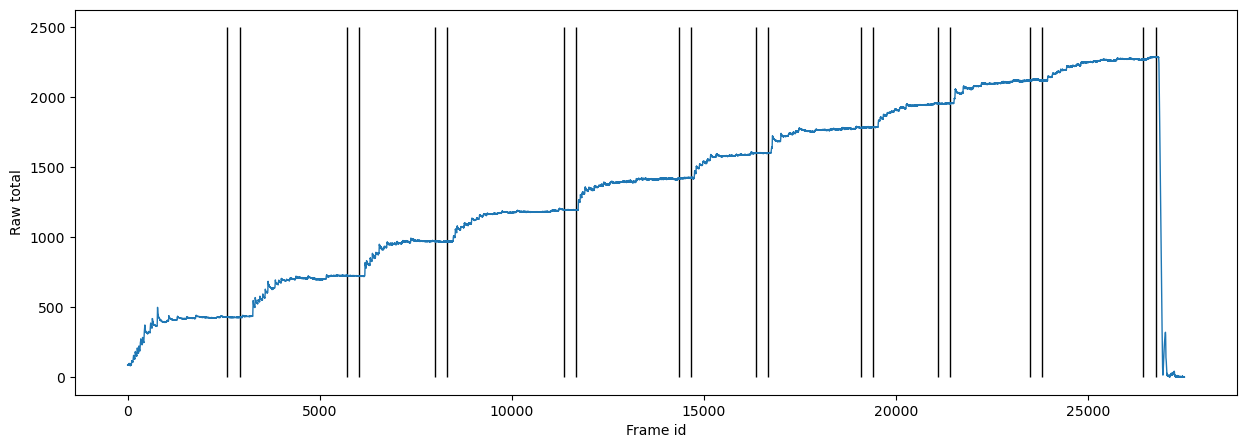

In [6]:
test_ids = {
    10: 2600,
    20: 5700,
    30: 8000,
    40: 11350,
    50: 14350,
    60: 16350,
    70: 19100,
    80: 21100,
    90: 23500,
    100: 26450
}

nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(15*ncols, 5*nrows))

for val in test_ids.values():
    ax.vlines([val, val+FRAME_WINDOW], ymin=0, ymax=2500, color='black', linewidth=1)

ax.plot(np.arange(len(test_Rs)), test_Rs, linewidth=1)
ax.set_xlabel('Frame id')
ax.set_ylabel('Raw total')
plt.show()

## Compute frame averages
- Take the average of the frame windows for each force level

In [7]:
def avg_frames(frames, frame_ids_dict):
    return {key: np.mean(frames[val:val+FRAME_WINDOW], axis=0) for key, val in frame_ids_dict.items()}

In [8]:
cal_frames = avg_frames(cal_imgs, cal_ids)
test_frames = avg_frames(test_imgs, test_ids)

In [16]:
from scipy.optimize import minimize_scalar
def compute_power_law_coeffs(cal_frames, sensel_area=1.6129):
    """
    P = ar^b\n
    P is pressure (MPa), r is sensel raw 8 bit value (F in N)
    """

    patches = [x for x in cal_frames.values()] # calibration patch arrays
    Fs = np.array([x for x in cal_frames.keys()], dtype=float) # known total loads
    xs = [np.asarray(p, dtype=float)[np.asarray(p) >= 3] for p in patches] # Loaded sensels only

    # Average pressure on each patch
    n = np.array([len(x) for x in xs], dtype=float)
    area = n * sensel_area
    p = Fs / area

    # Fit: p_i ≈ a * mean(X_i ** b)
    def S(b):
        return np.array([np.mean(x ** b) for x in xs])

    def a_of_b(b):
        s = S(b)
        w = area ** 2
        return np.dot(w * p, s) / np.dot(w * s, s)

    def J(b):
        s = S(b)
        a = a_of_b(b)
        return np.sum((area * (a * s - p)) ** 2)

    res = minimize_scalar(J, bounds=(0, 3), method="bounded")

    b = res.x
    a = a_of_b(b)

    return a, b

In [18]:
a, b = compute_power_law_coeffs(cal_frames)
test_frames_mpa = {f: a*x**b for f, x in test_frames.items()}

In [65]:
for F, frame in test_frames_mpa.items():
    print(f'Instron force: {F}')
    print(f'Tekscan force: {force_per_frame(frame.reshape(1, 11, 11))[0]:.2f}\n')

Instron force: 10
Tekscan force: 10.68

Instron force: 20
Tekscan force: 22.11

Instron force: 30
Tekscan force: 33.12

Instron force: 40
Tekscan force: 44.07

Instron force: 50
Tekscan force: 55.37

Instron force: 60
Tekscan force: 64.38

Instron force: 70
Tekscan force: 74.58

Instron force: 80
Tekscan force: 84.34

Instron force: 90
Tekscan force: 94.60

Instron force: 100
Tekscan force: 104.62



In [71]:
test_frames_mpa[50].max()

np.float64(6.723274723968404)

In [72]:
test_frames[50].max()

np.float64(179.003125)

In [83]:
cal_frames[400][cal_frames[400]>3].mean()

np.float64(104.09460227272727)

# Thoughts
- total force is really good
    - Could just use this and fit fea to match average pressure, contact area, and contact location?
- peak pressure looks really high
    - Don't use this for fea, just say that peak pressure was found to be very sensitive to calibration so less trustworthy?

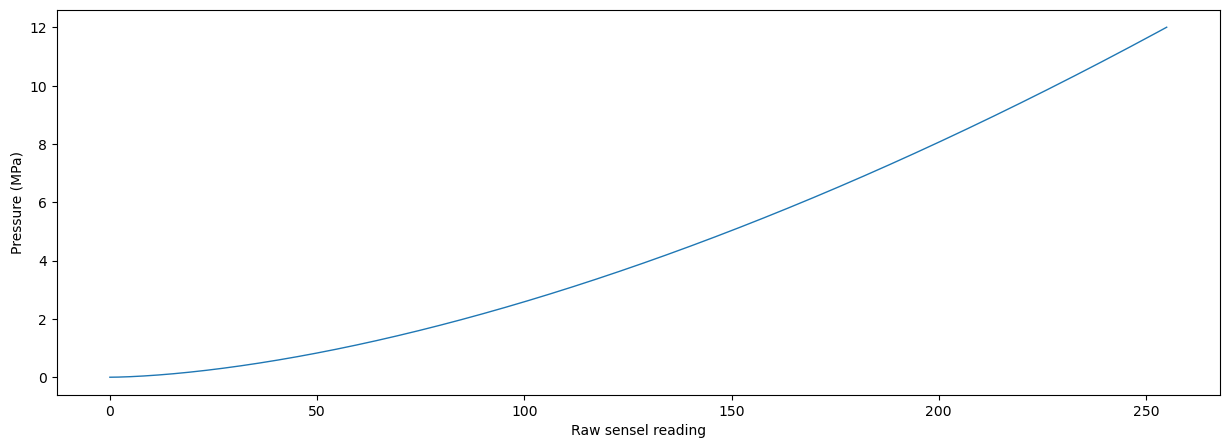

In [59]:
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(15*ncols, 5*nrows))

xs = np.linspace(0, 255, 1000)
ys = a*xs**b

ax.plot(xs, ys, linewidth=1)


ax.set_xlabel('Raw sensel reading')
ax.set_ylabel('Pressure (MPa)')
plt.show()